In [1]:
from Creador import generar_instancia_irp  
from Instancia import Instancia
from Proceso import Proceso
from Politica import PoliticaSimple, PoliticaSimpleClusterisada, RollOutSimple, RollOutCluster, MonteCarlo, MonteCarloRN, Qlearning, MonteCarlo_Fourier
from FuncionesAuxiliares import kmeans_clustering, visualizar_clusters, kmeans_clustering_sklearn
import numpy as np
import os
from Generador_de_instancias import n_instancias, generar_instancias, semillas
from Simulacion import Simulacion
from Resultados import Resultados
import matplotlib.pyplot as plt

In [2]:
#generar_instancias(semillas=semillas)

In [3]:
# Parámetros de la simulación
carpeta_instancias = "Instancias demandas bajas"
n_repeticiones = 1

# Ejecutar la simulación
#simulacion = Simulacion(carpeta_instancias, n_instancias = 10, n_repeticiones = n_repeticiones, n_repeticiones_rollout= 1)
#resultados = simulacion.ejecutar()

In [4]:
resultados = Resultados( nombre_archivo= 'resultadosPoliticasSimpleYCluster.xlsx')

resultados = resultados.leer_archivo()

No se encontró el archivo 'resultadosPoliticasSimpleYCluster.xlsx'. Asegúrate de que esté en la misma carpeta que el script.


In [5]:
resultados['Costo Traslado Simple'].mean()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
resultados['Costo Traslado Clusterizado'].mean()

np.float64(0.29877567857657605)

In [ ]:
resultados['Costo Total Simple'].mean()

np.float64(1897.5383064862312)

In [ ]:
resultados['Costo Total Clusterizado'].mean()

np.float64(2179.073354747131)

In [ ]:
resultados['Costo total Rollout Simple'].mean()

np.float64(1284.783988673995)

In [ ]:
resultados['Costo total RollOut Clusterizado'].mean()

np.float64(1139.2834645673354)

# EJECUCIÓN DE INSTANCIA DE EJEMPLO

In [2]:
# Generar instancia (ARCHIVO XML)
mensaje = generar_instancia_irp(
        ancho_zona = 2000, 
        largo_zona = 2000, 
        horizonte_tiempo = 400, 
        num_productos =2,
        num_clientes = 25, 
        num_vehiculos = 8, 
        semilla = 5, 
        carpeta_instancias= "Instancias demandas bajas 25C 400",
        nombre_archivo= 'instancia5.xml'
    )
    

In [2]:
carpeta_instancias = "Instancias demandas bajas 25C 400"
ruta_completa = os.path.join(carpeta_instancias, f'instancia9.xml')
# Lectura de la instancia y se guarda en un objeto instancia
instancia = Instancia(ruta_archivo=ruta_completa, umbral_inventario_clientes= 0.2, umbral_inventario_vehiculos= 0.1)
# Se genera el proceso mediante la instancia
proceso = Proceso(instancia)
politicaSimple = PoliticaSimple(instancia,proceso)
politicaClusterisada = PoliticaSimpleClusterisada(instancia,proceso)

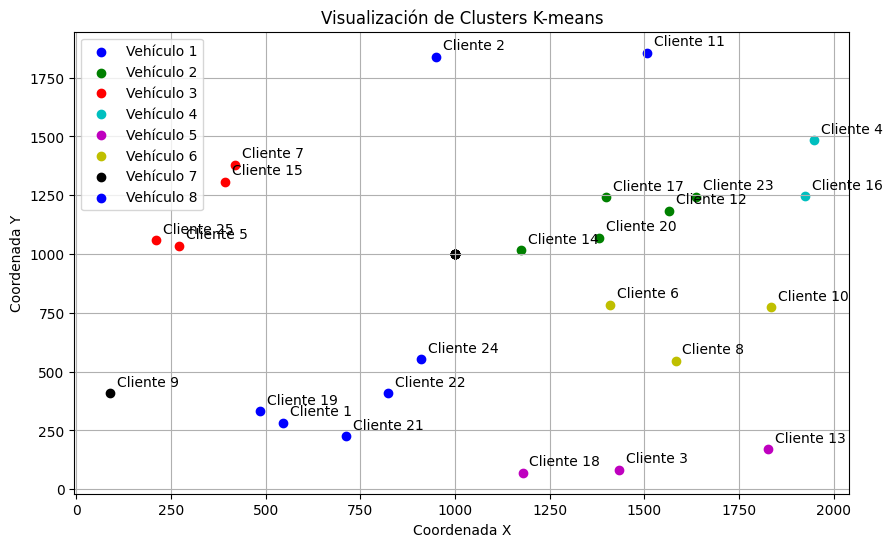

In [3]:
# Inicializamos el númmero de clusters
M = len(instancia.vehiculos.keys())
#Obtenemos las posiciones de los clientes
posiciones_clientes = { idc: {'x':cliente.posicion_x, 'y': cliente.posicion_y} for idc, cliente in instancia.clientes.items()}

# Ejecutar k-means (usando la función anterior)
clusters = kmeans_clustering_sklearn(M, posiciones_clientes)

# Visualizar resultados
visualizar_clusters(posiciones_clientes, clusters, {'x': instancia.depot_X, 'y': instancia.depot_Y})

In [4]:
print(f'los vehiculos son: \n {instancia.vehiculos}')
print(f'los clientes son:  \n {instancia.clientes}')
print(f'los productos son : \n {instancia.productos}')
print(f'las demandas medias son: {instancia.demandas_medias}')
print(instancia.depot_X)
print(instancia.depot_Y)

los vehiculos son: 
 {1: Vehiculo(id=1, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 2: Vehiculo(id=2, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 3: Vehiculo(id=3, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 4: Vehiculo(id=4, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 5: Vehiculo(id=5, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 6: Vehiculo(id=6, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 7: Vehiculo(id=7, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300}), 8: Vehiculo(id=8, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 300, 2: 300})}
los clientes son:  
 {1: Cliente(id=1, posicion_x=547.0, posicion_y=283.0, capacidad_almac

# Política simple

In [5]:
costos = np.array([])
traslado = np.array([])
n=50
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaSimple.run()  
    traslado  =  np.append(traslado,costo_traslado)
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_simple = np.mean(costos)
trasladdo_promedio = np.mean(traslado)
print(promedio_simple)
print(trasladdo_promedio)

for t in trayectoriaSimple:
    print(t['estado'])
    print(t['accion'])  # s3segundos

456361.10710926243
0.3135786522642985

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}, 16: {1: 10.0, 2: 10.0}, 17: {1: 10.0, 2: 10.0}, 18: {1: 10.0, 2: 10.0}, 19: {1: 10.0, 2: 10.0}, 20: {1: 10.0, 2: 10.0}, 21: {1: 10.0, 2: 10.0}, 22: {1: 10.0, 2: 10.0}, 23: {1: 10.0, 2: 10.0}, 24: {1: 10.0, 2: 10.0}, 25: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 300, 2: 300}, 2: {1: 300, 2: 300}, 3: {1: 300, 2: 300}, 4: {1: 300, 2: 300}, 5: {1: 300, 2: 300}, 6: {1: 300, 2: 300}, 7: {1: 300, 2: 300}, 8: {1: 300, 2: 300}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}

# Instancia Clusterizada

In [6]:
costos = np.array([])
traslado = np.array([])
n=50
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaClusterisada.run()
    traslado  =  np.append(traslado,costo_traslado)
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_cluster = np.mean(costos)
promedio_traslado = np.mean(traslado)
print(promedio_cluster)
print(promedio_traslado)


444069.34577490995
0.19780261542483113


# Implementamos la Rollout Simple ahora

In [7]:
PoliticaRollout = RollOutSimple(instancia= instancia, proceso= proceso)

costos = np.array([])

# ejecutamos 10 veces la política rollout
for _ in range(2):
    trayectoria_rollout,_,_ = PoliticaRollout.run()
    costo_episodio =  sum(i['recompensa'] for i in trayectoria_rollout)
    costos = np.append(costos,costo_episodio)

promedio_costo_rollout_simple = np.mean(costos)
print(promedio_costo_rollout_simple) # 13m

KeyboardInterrupt: 

# Ahora implementamos la RollOut clusterizada

In [8]:
PoliticaRolloutCluster = RollOutCluster( instancia= instancia, proceso= proceso)

costos = np.array([])
# ejecutamos 10 veces la política rollout cluster
for _ in range(2):
    trayectoria_rollout_cluster,_,_ = PoliticaRolloutCluster.run()
    costos = np.append(costos, sum( i['recompensa'] for i in trayectoria_rollout_cluster))
promedio_costo_rollout_cluster = np.mean(costos)
print(promedio_costo_rollout_cluster)
for t in trayectoria_rollout_cluster:
    print(t['estado'])
    print(t['accion']) #8m

439157.8444172165

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}, 16: {1: 10.0, 2: 10.0}, 17: {1: 10.0, 2: 10.0}, 18: {1: 10.0, 2: 10.0}, 19: {1: 10.0, 2: 10.0}, 20: {1: 10.0, 2: 10.0}, 21: {1: 10.0, 2: 10.0}, 22: {1: 10.0, 2: 10.0}, 23: {1: 10.0, 2: 10.0}, 24: {1: 10.0, 2: 10.0}, 25: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 278, 2: 320}, 2: {1: 278, 2: 320}, 3: {1: 278, 2: 320}, 4: {1: 278, 2: 320}, 5: {1: 278, 2: 320}, 6: {1: 278, 2: 320}, 7: {1: 278, 2: 320}, 8: {1: 278, 2: 320}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}}
        Tie

# implementamos la política MC OnPolicy

In [9]:
MC = MonteCarlo(instancia = instancia, proceso = proceso, episodios = 2000, epsilon=0.1, learning_rate=0.0001) # 4 para 200 periodos, 5 para 400 periodos episodios = 8000, epsilon=0.1, learning_rate=0.001 # lr 0.001 eps: 0.05

In [10]:
MC.entrenar_modelo() # 11m

KeyboardInterrupt: 

In [ ]:
MC.numero_de_features

318

In [ ]:
trayectoria_MC, traslado = MC.ejecutar_politica_mejores_betas()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MC)

115594.66356825727


np.float64(372019.66356825706)

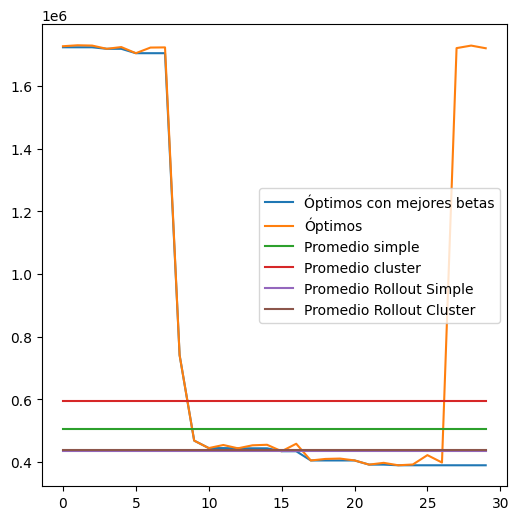

In [13]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,6))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster')
plt.legend() # Esto muestra las leyendas en el gráfico
plt.show()

# Q LEARNING

In [ ]:
Q_learning = Qlearning(instancia = instancia, proceso = proceso, episodios = 3000, epsilon = 0.05, learning_rate = 0.001, gamma = 0.9)  # lr = 0.001, gamma = 0.9 y epsilon = 0.01

In [15]:
Q_learning.entrenar_modelo() #20

# MC FOURIER

In [ ]:
MC_fourier = MonteCarlo_Fourier(instancia = instancia, proceso = proceso, episodios = 3000, epsilon=0.1, learning_rate=0.0001, max_i= 5) # 4 para 200 periodos, 5 para 400 periodos episodios = 8000, epsilon=0.1, learning_rate=0.001 # lr 0.001 eps: 0.05

In [17]:
MC_fourier.entrenar_modelo() #13m

In [21]:
print(round(promedio_simple))
print(round(promedio_cluster))
print(round(promedio_costo_rollout_simple))
print(round(promedio_costo_rollout_cluster))
print(round(MC.registro_optimos_mejores_betas[len(MC.registro_optimos_mejores_betas)-1]))
print(round(Q_learning.registro_optimos_mejores_betas[len(MC.registro_optimos_mejores_betas)-1]))
print(round(MC_fourier.registro_optimos_mejores_betas[len(MC_fourier.registro_optimos_mejores_betas)-1]))

506470
595113
436414
439158
389289
474791
343883


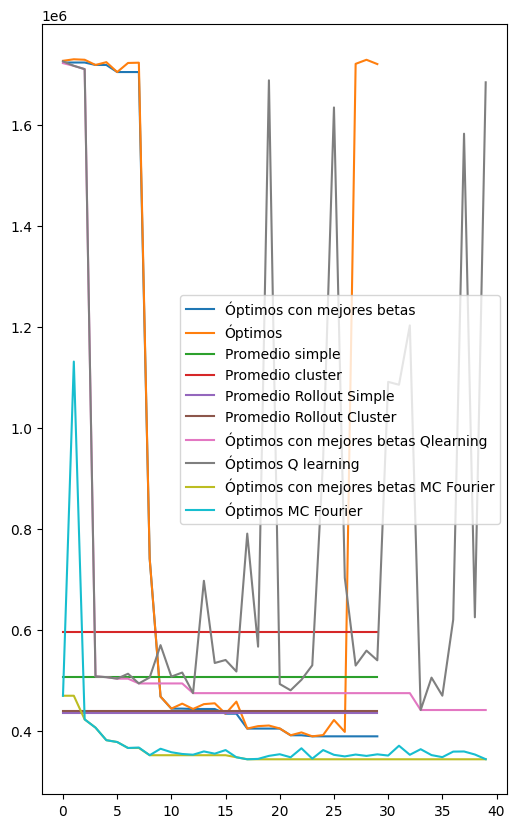

In [22]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(6,10))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster')
plt.plot(Q_learning.registro_optimos_mejores_betas, label='Óptimos con mejores betas Qlearning')
plt.plot(Q_learning.registro_optimos, label='Óptimos Q learning')
plt.plot(MC_fourier.registro_optimos_mejores_betas, label='Óptimos con mejores betas MC Fourier')
plt.plot(MC_fourier.registro_optimos, label='Óptimos MC Fourier')
plt.legend() # Esto muestra las leyendas en el gráfico
plt.show()

# Redes neuronales

In [20]:
MC_RN = MonteCarloRN(instancia = instancia, proceso = proceso, episodios = 1, epsilon = 0.05, learning_rate = 0.001)

In [5]:
MC_RN.entrenar_modelo()

In [6]:
trayectoria_MCRN, traslado = MC_RN.ejecutar_politica_RedNeuronal()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MCRN)

25779.340944448646


np.float64(504792.34094444866)

In [34]:
334861
378429
288789

288789